# A02 - Fidelity/Throughput Trade-off

## Objetivo
Mostrar o trade-off entre fidelidade requisitada, fidelidade observada,
pares entregues e throughput, comparando `NeverPurify` ("disabled") e
`PurifyUntilTarget` ("automatic"), usando os dados reais e já persistidos
da campanha `C02_fidelity_throughput` (20 trials: 5 limiares de fidelidade
x 2 políticas x 2 seeds). Este notebook **não roda nenhuma simulação**.

## Conceitos
- Nesta topologia (`three_node.yaml`), o teto de fidelidade sem
  purificação é ~0.6864 (produto das fidelidades elementares x degradação
  do swap); com um round de purificação (`BBPSSWCircuit.improved_fidelity`),
  o teto sobe para ~0.7203 - mas não além disso nesta versão do planner
  (notebook 17 da Fase H2).
- Um requisito de fidelidade acima do teto alcançável faz o `IntentPlanner`
  rejeitar o intent **antes** de qualquer simulação (`REJECTED`) - não é
  uma falha observada, é uma inviabilidade detectada no planejamento.


## Configuração


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from ibqn.experiments.persistence import read_trials_dataframe, trials_csv_path
from ibqn.experiments.aggregation import aggregate_records
from ibqn.experiments.export import save_figure, save_table

RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures" / "article"
TABLES_DIR = RESULTS_DIR / "tables" / "article"
CAMPAIGN = "C02_fidelity_throughput"

trials_df = read_trials_dataframe(trials_csv_path(RESULTS_DIR, CAMPAIGN))
trials_df[["purification_policy", "requested_fidelity", "seed", "final_status", "delivered_pairs", "average_fidelity"]]


,purification_policy,requested_fidelity,seed,final_status,delivered_pairs,average_fidelity
0,disabled,0.65,0,SATISFIED,237.0,0.686375
1,disabled,0.65,1000,SATISFIED,247.0,0.686375
2,automatic,0.65,0,SATISFIED,237.0,0.686375
3,automatic,0.65,1000,SATISFIED,247.0,0.686375
4,disabled,0.70,0,REJECTED,NaN,NaN
5,disabled,0.70,1000,REJECTED,NaN,NaN
6,automatic,0.70,0,SATISFIED,54.0,0.720252
7,automatic,0.70,1000,SATISFIED,58.0,0.720252
8,disabled,0.72,0,REJECTED,NaN,NaN
9,disabled,0.72,1000,REJECTED,NaN,NaN


## Execução


In [2]:
aggregated_df = aggregate_records(
    trials_df, group_by=["purification_policy", "requested_fidelity"],
    metrics=["average_fidelity", "delivered_pairs", "throughput_active_window"],
)
pivot_fidelity = aggregated_df[aggregated_df["metric"] == "average_fidelity"].pivot(
    index="requested_fidelity", columns="purification_policy", values="mean"
)
pivot_fidelity


purification_policy,automatic,disabled
requested_fidelity,,
0.65,0.686375,0.686375
0.70,0.720252,NaN
0.72,0.720252,NaN
0.75,NaN,NaN
0.85,NaN,NaN


## Resultados


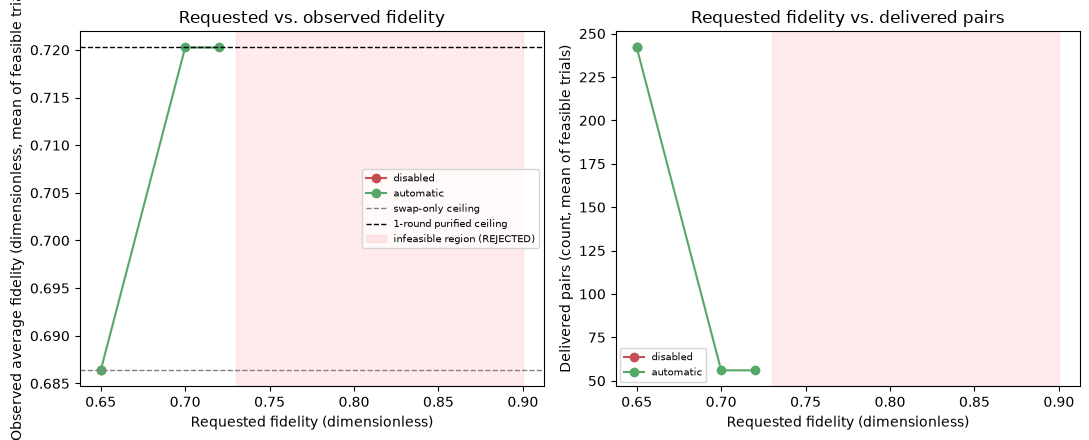

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for policy, color in [("disabled", "#C44E52"), ("automatic", "#55A868")]:
    subset = aggregated_df[aggregated_df["purification_policy"] == policy]
    fidelity_rows = subset[subset["metric"] == "average_fidelity"].sort_values("requested_fidelity")
    axes[0].plot(fidelity_rows["requested_fidelity"], fidelity_rows["mean"], marker="o", label=policy, color=color)

    pairs_rows = subset[subset["metric"] == "delivered_pairs"].sort_values("requested_fidelity")
    axes[1].plot(pairs_rows["requested_fidelity"], pairs_rows["mean"], marker="o", label=policy, color=color)

axes[0].set_xlabel("Requested fidelity (dimensionless)")
axes[0].set_ylabel("Observed average fidelity (dimensionless, mean of feasible trials)")
axes[0].axhline(0.6864, color="gray", linestyle="--", linewidth=1, label="swap-only ceiling")
axes[0].axhline(0.7203, color="black", linestyle="--", linewidth=1, label="1-round purified ceiling")
axes[0].axvspan(0.73, 0.90, color="red", alpha=0.08, label="infeasible region (REJECTED)")
axes[0].set_title("Requested vs. observed fidelity")
axes[0].legend(fontsize=7)

axes[1].set_xlabel("Requested fidelity (dimensionless)")
axes[1].set_ylabel("Delivered pairs (count, mean of feasible trials)")
axes[1].axvspan(0.73, 0.90, color="red", alpha=0.08)
axes[1].set_title("Requested fidelity vs. delivered pairs")
axes[1].legend(fontsize=7)

fig.tight_layout()
save_figure(fig, "A02_fidelity_throughput_tradeoff", directory=FIGURES_DIR)
plt.show()


In [4]:
rejection_by_policy_and_fidelity = (
    trials_df.groupby(["purification_policy", "requested_fidelity"])["final_status"]
    .apply(lambda statuses: (statuses == "REJECTED").mean())
    .rename("rejection_rate")
    .reset_index()
)
save_table(rejection_by_policy_and_fidelity, "A02_rejection_rate_by_policy_and_fidelity", directory=TABLES_DIR)
rejection_by_policy_and_fidelity


,purification_policy,requested_fidelity,rejection_rate
0,automatic,0.65,0.0
1,automatic,0.70,0.0
2,automatic,0.72,0.0
3,automatic,0.75,1.0
4,automatic,0.85,1.0
5,disabled,0.65,0.0
6,disabled,0.70,1.0
7,disabled,0.72,1.0
8,disabled,0.75,1.0
9,disabled,0.85,1.0


In [5]:
disabled_070 = trials_df[(trials_df["purification_policy"] == "disabled") & (trials_df["requested_fidelity"] == 0.70)]
automatic_070 = trials_df[(trials_df["purification_policy"] == "automatic") & (trials_df["requested_fidelity"] == 0.70)]
assert (disabled_070["final_status"] == "REJECTED").all(), "NeverPurify must be rejected at 0.70 (above the swap-only ceiling)"
assert (automatic_070["final_status"] == "SATISFIED").all(), "PurifyUntilTarget must satisfy 0.70 (below the purified ceiling)"

both_085 = trials_df[trials_df["requested_fidelity"] == 0.85]
assert (both_085["final_status"] == "REJECTED").all(), "both policies must be rejected at 0.85 (above even the purified ceiling)"
print("Confirmed: purification extends the feasible range, but both policies share the same hard ceiling above ~0.72.")


Confirmed: purification extends the feasible range, but both policies share the same hard ceiling above ~0.72.


## Interpretação
Abaixo de ~0.6864, as duas políticas produzem o mesmo resultado (a
purificação nunca é necessária). Entre ~0.6864 e ~0.7203, `disabled` é
sistematicamente `REJECTED` (o planner já sabe que o swap isolado não
basta) enquanto `automatic` satisfaz o intent, com fidelidade observada
mais alta e menos pares entregues por unidade de tempo (o custo real da
purificação). Acima de ~0.7203, **nenhuma das duas políticas** consegue
satisfazer o requisito - o teto de fidelidade desta versão do planner (um
único round analítico de purificação) é uma limitação física real, não
uma falta de tentativa.

## Limitações
- `n=2` seeds por combinação - descritivo, não estatisticamente robusto
  (`docs/campaign_architecture.md`, seção 10).
- O teto de ~0.7203 é específico desta topologia (`raw_fidelity=0.85`,
  `swapping_degradation=0.95`); outras topologias têm outro teto.

## Conclusão
O trade-off fidelidade/throughput demonstrado com dados reais: purificação
expande a faixa de fidelidade alcançável, mas até um teto físico real,
acima do qual ambas as políticas são igualmente rejeitadas.
